# Figs: metabolic cost pvae

project = ```P-VAE```, host = ```chewie```, device = ```cuda:1```

**Motivation**: <br>

Goal: `MetabolicCost`

In [1]:
# HIDE CODE


project_name = 'PoissonVAE'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.fighelper import *
from main.train_vae import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

## Results dir

In [3]:
results_dir = pjoin(tmp_dir, 'results_2025-10')
fits = [f for f in os.listdir(results_dir) if 'MetabolicCost' in f]
fits = sorted(fits, key=alphanum_sort_key)

len(fits)

176

## Load results

In [4]:
info_keys = ['str_model', 'n_latents', 'kl_beta']

df_metabolic_cost = collections.defaultdict(list)

for f in tqdm(fits):
    load = np.load(pjoin(results_dir, f), allow_pickle=True).item()
    info, results = load['info'], load['results']
    
    # info
    for k in info_keys:
        df_metabolic_cost[k].append(
            info.get(k, None))

    # results
    r2 = results['r2']
    portion_zeros = results['%-zeros']
    euc_dist = np.sqrt(
        (1 - r2) ** 2 +
        (1 - portion_zeros) ** 2
    )
    df_metabolic_cost['r2'].append(r2)
    df_metabolic_cost['portion_zeros'].append(portion_zeros)
    df_metabolic_cost['euc_dist'].append(euc_dist)

    df_metabolic_cost['lifetime'].append(results['lifetime'])
    df_metabolic_cost['samples_mean'].append(
        results['samples_final'].mean())
    df_metabolic_cost['posterior_mean'].append(
        results['posterior_mean'])

df_metabolic_cost = pd.DataFrame(df_metabolic_cost)

100%|█████████████████████████████████████████| 176/176 [00:07<00:00, 22.51it/s]


In [5]:
info

{'checkpoint': 3000,
 'timestamp': '2025_10_12,21:58',
 'seed': 0,
 'dataset': 'vH16',
 'type': 'poisson',
 'latent_act': None,
 'n_latents': 768,
 'str_model': 'poisson+amort',
 'archi': '<lin|lin>',
 'seq_len': 1,
 'kl_beta': 8.0,
 'n_params': 393984,
 'n_iters_train': 312000}

In [6]:
df_metabolic_cost

,str_model,n_latents,kl_beta,r2,portion_zeros,euc_dist,lifetime,samples_mean,posterior_mean
0,gaussian+relu+amort,1024,0.01,0.964995,0.487964,0.513231,0.677409,0.518248,0.518151
1,gaussian+relu+amort,128,0.01,0.732195,0.104071,0.935098,0.401691,2.054607,2.054527
2,gaussian+relu+amort,192,0.01,0.864081,0.116711,0.893685,0.414736,1.830454,1.830445
3,gaussian+relu+amort,2048,0.01,0.964603,0.494059,0.507177,0.679575,0.458564,0.458589
4,gaussian+relu+amort,256,0.01,0.915357,0.136310,0.867827,0.433270,1.604068,1.604177
...,...,...,...,...,...,...,...,...,...
171,poisson+amort,384,8.00,-0.010618,0.997281,1.010622,0.997357,0.159962,0.159922
172,poisson+amort,4096,8.00,-0.010879,0.999720,1.010879,0.999745,0.014725,0.014719
173,poisson+amort,512,8.00,-0.010499,0.997947,1.010501,0.998013,0.119269,0.119245
174,poisson+amort,64,8.00,-0.010620,0.984139,1.010744,0.984421,0.964347,0.964708


In [7]:
sorted(df_metabolic_cost['n_latents'].unique())

[32, 64, 128, 192, 256, 384, 512, 768, 1024, 2048, 4096]

In [8]:
sorted(df_metabolic_cost['kl_beta'].unique())

[0.01, 0.1, 0.5, 1.0, 1.5, 2.0, 4.0, 8.0]

## plot figs

In [9]:
fig_dir = 'results_metabolic_cost'
fig_dir = pjoin(fig_base_dir, fig_dir)
os.makedirs(fig_dir, exist_ok=True)

sorted(os.listdir(fig_dir))

['portion_zeros.pdf',
 'portion_zeros_pie.pdf',
 'posterior_means.pdf',
 'posterior_sample_means.pdf']

In [10]:
pal = get_palette()[0]
selected_k = [64, 128, 192, 256, 384, 512, 1024, 2048]

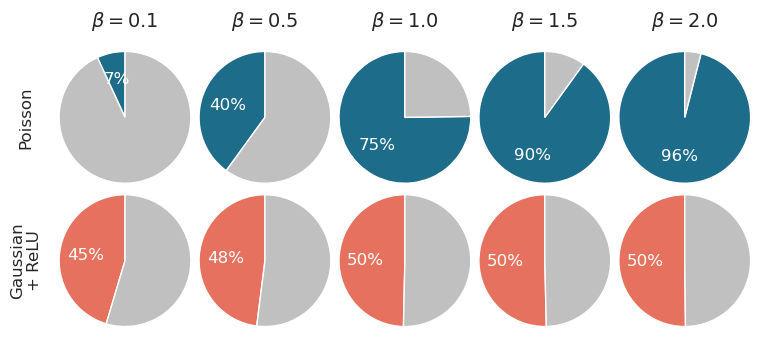

In [11]:
str_models = ['poisson+amort', 'gaussian+relu+amort']
kl_betas = [0.1, 0.5, 1.0, 1.5, 2.0]
n_latents = 512

fig, axes = create_figure(
    nrows=len(str_models),
    ncols=len(kl_betas),
    figsize=(10, 4.0),
    hspace=-0.13,
    wspace=-0.35,
    cnst=False,
)

for i, s in enumerate(str_models):
    for j, b in enumerate(kl_betas):
        data = df_metabolic_cost.loc[
            (df_metabolic_cost['kl_beta'] == b) &
            (df_metabolic_cost['str_model'] == s) &
            (df_metabolic_cost['n_latents'] == n_latents)
        ]

        # Extract data
        data = data.to_dict(orient='records')[0]
        pz = data['portion_zeros']
        sizes = [pz, 1 - pz]

        # Determine color
        key = data['str_model'].replace('+amort', '').replace('+', '-')
        color_main = pal[key]
        colors = [color_main, 'silver']

        ax = axes[i, j]
        
        # Capture the return values to modify text properties
        wedges, texts, autotexts = ax.pie(
            sizes, 
            colors=colors, 
            startangle=90, 
            autopct='%.0f%%'
        )
    
        # autotexts[0] is the percentage for the first slice (portion_zeros)
        autotexts[0].set_color('white')

        # autotexts[1] is the percentage for the remainder; hide it
        autotexts[1].set_visible(False)

        # Labels
        if i == 0:
            ax.set_title(f'$\\beta = {b}$', fontsize=14)
        if j == 0:
            text = 'Poisson' if 'poisson' in s else 'Gaussian\n+ ReLU'
            ax.text(
                -0.1, 0.5, text, transform=ax.transAxes, 
                va='center', ha='center', fontsize=12, rotation=90)

fig.savefig(pjoin(fig_dir, 'portion_zeros_pie.pdf'), bbox_inches='tight')
plt.show()

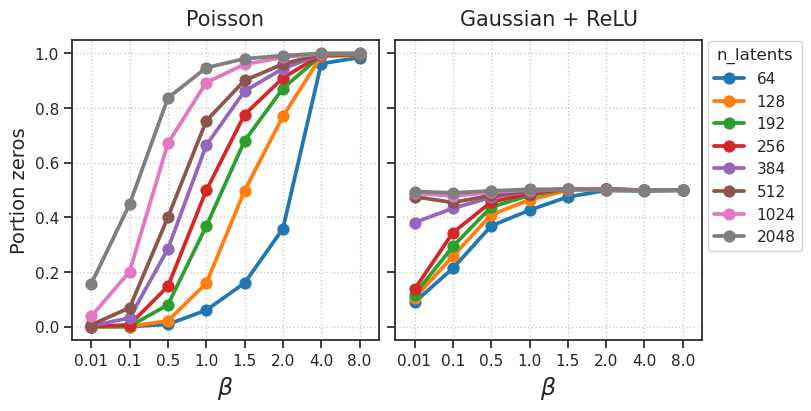

In [12]:
kws = dict(x='kl_beta', y='portion_zeros', hue='n_latents', palette='tab10', legend=False)


fig, axes = create_figure(1, 2, (8, 4), sharey='all')

kws['data'] = df_metabolic_cost.loc[
    (df_metabolic_cost['str_model'] == 'poisson+amort') &
    (df_metabolic_cost['n_latents'].isin(selected_k))
]
sns.pointplot(ax=axes[0], **kws)

kws['data'] = df_metabolic_cost.loc[
    (df_metabolic_cost['str_model'] == 'gaussian+relu+amort') &
    (df_metabolic_cost['n_latents'].isin(selected_k))
]
kws['legend'] = True
sns.pointplot(ax=axes[1], **kws)

axes[0].set_title('Poisson', fontsize=15, y=1.02)
axes[1].set_title('Gaussian + ReLU', fontsize=15, y=1.02)

axes[0].set_ylabel('Portion zeros', fontsize=14)
axes[0].set_xlabel(r'$\beta$', fontsize=17)
axes[1].set_xlabel(r'$\beta$', fontsize=17)

# ax.set(yscale='log')

move_legend(axes[1], bbox=(1.35, 1.02))

add_grid(axes)

fig.savefig(pjoin(fig_dir, 'portion_zeros.pdf'), bbox_inches='tight')
plt.show()

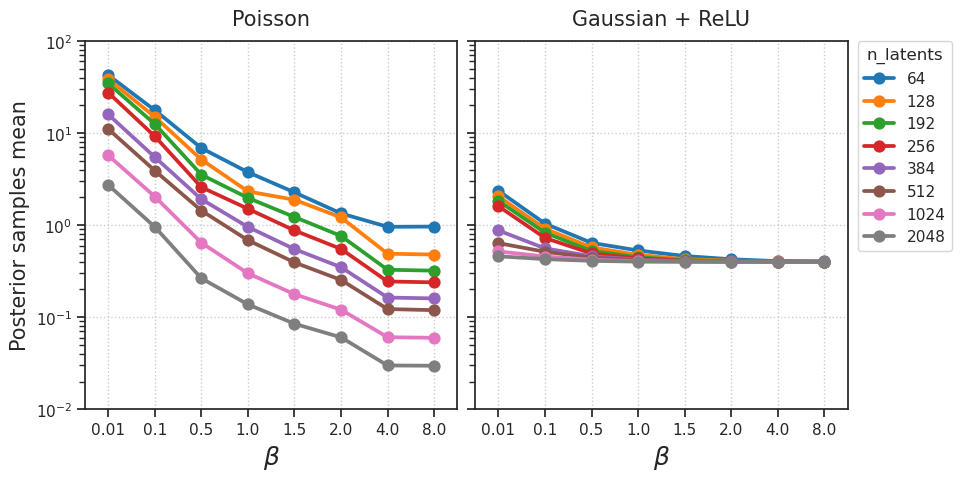

In [13]:
kws = dict(x='kl_beta', y='samples_mean', hue='n_latents', palette='tab10')

fig, axes = create_figure(1, 2, (9.5, 4.7), sharey='row')

ax = axes[0]
ax.set(yscale='log', ylim=(1e-2, 1e2))
ax.set_ylabel('Posterior samples mean', fontsize=15)

_df = df_metabolic_cost.loc[
    (df_metabolic_cost['n_latents'].isin(selected_k)) &
    (df_metabolic_cost['str_model'] == 'poisson+amort')
]
sns.pointplot(data=_df, ax=ax, legend=False, **kws)

ax = axes[1]
_df = df_metabolic_cost.loc[
    (df_metabolic_cost['n_latents'].isin(selected_k)) &
    (df_metabolic_cost['str_model'] == 'gaussian+relu+amort')
]
sns.pointplot(data=_df, ax=ax, legend=True, **kws)

move_legend(ax, (1.3, 1.02))

axes[0].set_title('Poisson', fontsize=15, y=1.02)
axes[1].set_title('Gaussian + ReLU', fontsize=15, y=1.02)

for ax in axes.flat:
    ax.set_xlabel(r'$\beta$', fontsize=18)
    ax.grid()

fig.savefig(pjoin(fig_dir, 'posterior_sample_means.pdf'), bbox_inches='tight')
plt.show()

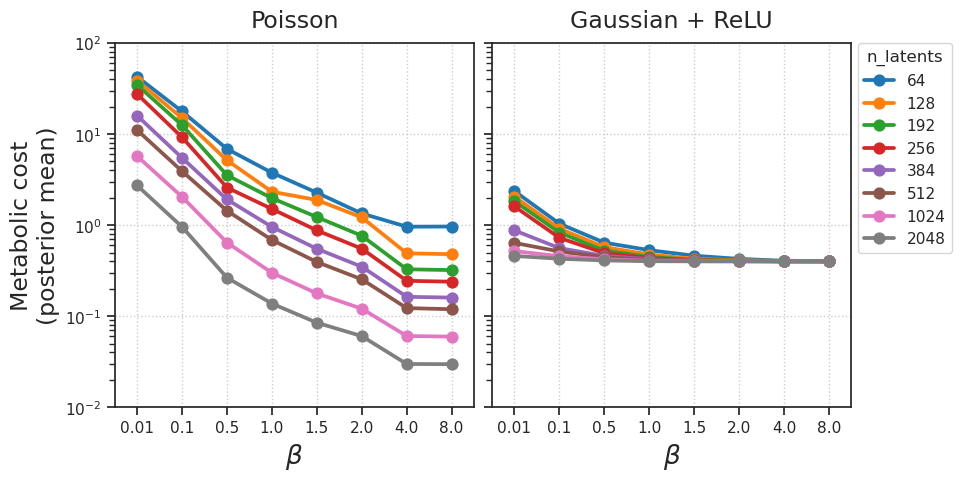

In [14]:
kws = dict(x='kl_beta', y='posterior_mean', hue='n_latents', palette='tab10')

fig, axes = create_figure(1, 2, (9.5, 4.7), sharey='row')

ax = axes[0]
ax.set(yscale='log', ylim=(1e-2, 1e2))
ax.set_ylabel('Metabolic cost\n(posterior mean)', fontsize=17)

_df = df_metabolic_cost.loc[
    (df_metabolic_cost['n_latents'].isin(selected_k)) &
    (df_metabolic_cost['str_model'] == 'poisson+amort')
]
sns.pointplot(data=_df, ax=ax, legend=False, **kws)

ax = axes[1]
_df = df_metabolic_cost.loc[
    (df_metabolic_cost['n_latents'].isin(selected_k)) &
    (df_metabolic_cost['str_model'] == 'gaussian+relu+amort')
]
sns.pointplot(data=_df, ax=ax, legend=True, **kws)

move_legend(ax, (1.3, 1.02))

axes[0].set_title('Poisson', fontsize=17, y=1.02)
axes[1].set_title('Gaussian + ReLU', fontsize=17, y=1.02)

for ax in axes.flat:
    ax.set_xlabel(r'$\beta$', fontsize=19)
    ax.grid()

fig.savefig(pjoin(fig_dir, 'posterior_means.pdf'), bbox_inches='tight')
plt.show()

In [20]:
pal

{'poisson-0.01': (0.52478243, 0.74477453, 0.56881287),
 'poisson-0.2': (0.40783143, 0.68627814, 0.56595436),
 'poisson-0.4': (0.31270304, 0.62072111, 0.56379321),
 'poisson-0.6': (0.23921167, 0.55556705, 0.55758211),
 'poisson-0.8': (0.1657302, 0.48845913, 0.54959882),
 'poisson': (0.11409965, 0.42169502, 0.54065622),
 'poisson-1.5': (0.12274959, 0.34740723, 0.52136104),
 'poisson-4': (0.15459955, 0.27155765, 0.4865371),
 'gaussian-relu': (0.89737819, 0.44322747, 0.37043052),
 'gaussian': (0.75861834, 0.25356035, 0.40663694),
 'gaussian-exp': (0.52386353, 0.18939409, 0.44182449),
 'laplace': (0.41568627450980394, 0.8, 0.39215686274509803),
 'categorical': (0.5490196078431373, 0.3803921568627451, 0.23529411764705882),
 'lca': '#6f6f6f',
 'ista': '#aeaeae'}

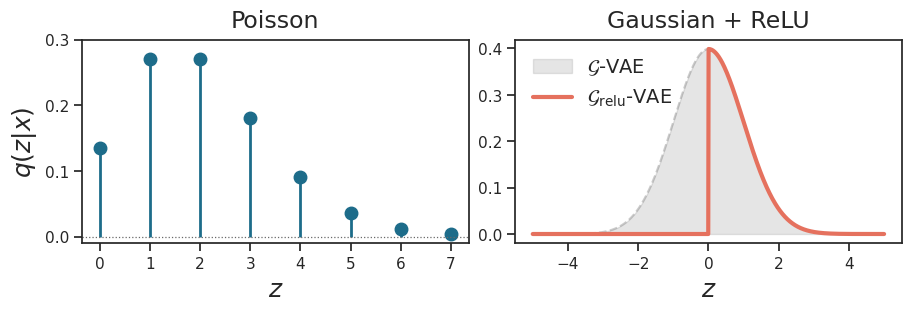

In [71]:
fig, axes = create_figure(nrows=1, ncols=2, figsize=(9, 3))

# --- Left Plot: Poisson ---
ax = axes[0]
lamb = 2
x_k = np.arange(0, 8)
y_pmf = sp_stats.poisson.pmf(x_k, lamb)

ax.vlines(x_k, 0, y_pmf, colors=pal['poisson'], lw=2)
ax.plot(x_k, y_pmf, 'o', color=pal['poisson'], markersize=9)
ax.axhline(0, color='dimgrey', ls=':', lw=0.9)
ax.set_ylim((-0.01, 0.3))

# --- Right Plot: Truncated Gaussian (ReLU) ---
ax = axes[1]
x_grid = np.linspace(-5, 5, 1000)
y_pdf = sp_stats.norm.pdf(x_grid, loc=0, scale=1)

# 1. Full Gaussian Background (low alpha)
# We fill the area to make the "background" aspect clear
ax.fill_between(x_grid, y_pdf, color='grey', alpha=0.2, label=r'$\mathcal{G}$-VAE')
ax.plot(x_grid, y_pdf, color='grey', alpha=0.4, linestyle='--')

# 2. ReLU Truncated Version (Gaussian + ReLU)
# Value is 0 for x < 0, follows Gaussian PDF for x > 0
y_relu = np.where(x_grid < 0, 0, y_pdf)

ax.plot(x_grid, y_relu, color=pal['gaussian-relu'], lw=3, label=r'$\mathcal{G}_\mathrm{relu}$-VAE')
ax.legend(fontsize=14, frameon=False)

axes[0].set_ylabel(r'$q(z \vert x)$', fontsize=18)
axes[0].set_xlabel(r'$z$', fontsize=18)
axes[1].set_xlabel(r'$z$', fontsize=18)
axes[0].set_title('Poisson', fontsize=17, y=1.02)
axes[1].set_title('Gaussian + ReLU', fontsize=17, y=1.02)


fig.savefig(pjoin(fig_dir, 'poisson_grelu.pdf'), bbox_inches='tight')
plt.show()

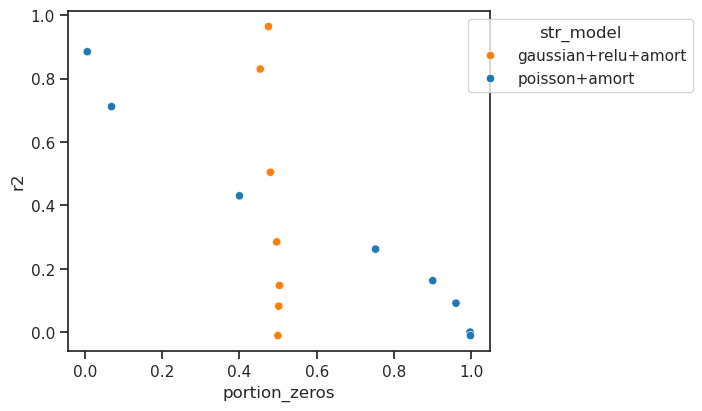

In [23]:
fig, ax = create_figure(1, 1, (6.5, 4))

_df = df_metabolic_cost.loc[df_metabolic_cost['n_latents'] == 512]

sns.scatterplot(
    data=_df,
    x='portion_zeros',
    y='r2',
    hue='str_model',
    palette={'poisson+amort': 'C0', 'gaussian+relu+amort': 'C1'},
    ax=ax,
)
move_legend(ax, [1.5, 1])
plt.show()